# Card Classification With Distance Maps

Detect cards and specials, then classify each detected card by comparing its extracted crop to the saved category distance maps in `card_distance_maps/`. Specials are reported directly from the detector.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from card_detection import (
    DEFAULT_COLORS,
    CardDetectionPaths,
    detect_cards_in_image,
    load_card_template,
    load_color_thresholds,
    load_image,
    load_rectangle_settings,
    load_threshold_rectangle_settings,
    show_detection_result,
)

BASE_DIR = Path.cwd()
PATHS = CardDetectionPaths(BASE_DIR)
DISTANCE_MAPS_DIR = BASE_DIR / "card_distance_maps"

IMAGE_NAME = "L1000850.jpg"
DETECTION_COLORS = DEFAULT_COLORS
SCALE = 0.25
REMOVAL_MAKE_CONVEX = True
SHOW_DETECTION_PROGRESS = True

image_path = PATHS.train_dir / IMAGE_NAME
if not image_path.exists():
    image_path = PATHS.reference / IMAGE_NAME
if not image_path.exists():
    raise FileNotFoundError(f"Could not find {IMAGE_NAME} in train or reference images")

detect_special = image_path.parent.resolve() != PATHS.reference.resolve()

image_bgr, image_rgb = load_image(image_path)
card_template_mask = load_card_template(PATHS.card_template_mask)
color_thresholds = load_color_thresholds(PATHS, DEFAULT_COLORS)
rectangle_defaults = load_rectangle_settings(PATHS.rectangle_settings)
rectangle_settings = load_threshold_rectangle_settings(PATHS.threshold_rectangle_settings, rectangle_defaults)

print("Image:", image_path.name)
print("Special detection:", detect_special)
print("Distance maps dir:", DISTANCE_MAPS_DIR)

Image: L1000850.jpg
Special detection: True
Distance maps dir: c:\Users\ayoub\Code\IAPR_gr69\project\card_distance_maps


In [2]:
def load_distance_maps(distance_maps_dir: Path) -> dict[str, np.ndarray]:
    maps = {}
    for path in sorted(distance_maps_dir.glob("*.npy")):
        maps[path.stem] = np.load(path).astype(np.float32)
    if not maps:
        raise FileNotFoundError(f"No .npy distance maps found in {distance_maps_dir}")
    return maps


def card_symbol_mask(crop_rgb: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)
    non_white = gray < 245
    mask = non_white.astype(np.uint8) * 255
    kernel = np.ones((3, 3), dtype=np.uint8)
    return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)


def score_distance_map(mask: np.ndarray, distance_map: np.ndarray) -> float:
    resized_map = cv2.resize(distance_map, (mask.shape[1], mask.shape[0]), interpolation=cv2.INTER_LINEAR)
    foreground = mask > 0
    if not np.any(foreground):
        return 0.0
    return float(np.mean(resized_map[foreground]))


def candidate_distance_maps(color: str, distance_maps: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    if color == "black":
        return {category: distance_maps[category] for category in ("draw_4", "wild") if category in distance_maps}
    return {category: distance_map for category, distance_map in distance_maps.items() if category not in {"draw_4", "wild"}}


def classify_card(crop_rgb: np.ndarray, color: str, distance_maps: dict[str, np.ndarray]) -> tuple[str, float, str, list[tuple[str, float, str]]]:
    maps = candidate_distance_maps(color, distance_maps)
    if not maps:
        raise ValueError(f"No distance maps available for color {color}")

    orientations = [
        ("normal", crop_rgb),
        ("rot180", cv2.rotate(crop_rgb, cv2.ROTATE_180)),
    ]
    scores = []
    for orientation, oriented_crop in orientations:
        mask = card_symbol_mask(oriented_crop)
        for category, distance_map in maps.items():
            scores.append((category, score_distance_map(mask, distance_map), orientation))
    scores.sort(key=lambda item: item[1], reverse=True)
    best_category, best_score, best_orientation = scores[0]
    return best_category, best_score, best_orientation, scores


distance_maps = load_distance_maps(DISTANCE_MAPS_DIR)
print(f"Loaded {len(distance_maps)} distance maps:", sorted(distance_maps))


Loaded 15 distance maps: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'draw_2', 'draw_4', 'reverse', 'skip', 'wild']


In [3]:
result = detect_cards_in_image(
    image_bgr=image_bgr,
    image_rgb=image_rgb,
    color_thresholds=color_thresholds,
    rectangle_settings=rectangle_settings,
    card_template_mask=card_template_mask,
    colors=DETECTION_COLORS,
    scale=SCALE,
    detect_special=detect_special,
    removal_make_convex=REMOVAL_MAKE_CONVEX,
    show_progress=SHOW_DETECTION_PROGRESS,
)

classifications = []
card_index = 0
for row in result.rows:
    if row.get("kind"):
        classifications.append({
            "rank": row["rank"],
            "type": "special",
            "color": row["color"],
            "prediction": row["kind"],
            "score": row["score"],
            "row": row,
        })
        continue

    crop_title, crop_rgb = result.cards[card_index]
    card_index += 1
    prediction, score, orientation, scores = classify_card(crop_rgb, row["color"], distance_maps)
    classifications.append({
        "rank": row["rank"],
        "type": "card",
        "color": row["color"],
        "prediction": prediction,
        "score": score,
        "orientation": orientation,
        "top_scores": scores[:5],
        "crop_title": crop_title,
        "crop_rgb": crop_rgb,
        "row": row,
    })

print(f"Detected cards: {len(result.cards)}")
print(f"Rows: {len(result.rows)}")
for item in classifications:
    if item["type"] == "special":
        print(f"#{item['rank']}: special {item['color']} -> {item['prediction']} score={item['score']:.2f}")
    else:
        top = ", ".join(f"{category}:{score:.3f}/{orientation}" for category, score, orientation in item["top_scores"])
        print(f"#{item['rank']}: {item['color']} card -> {item['prediction']} ({item['orientation']}) score={item['score']:.3f} top=[{top}]")

Detecting specials


black candidates:   0%|          | 0/1 [00:00<?, ?it/s]

black candidates: threshold/cleanup black
black candidates: template matching black


blue candidates:   0%|          | 0/1 [00:00<?, ?it/s]

blue candidates: threshold/cleanup blue
blue candidates: template matching blue
Extracting #2 blue
Extracting #3 blue


...

red candidates: threshold/cleanup red
red candidates: template matching red
Extracting #4 red


yellow candidates:   0%|          | 0/1 [00:00<?, ?it/s]

yellow candidates: threshold/cleanup yellow
yellow candidates: template matching yellow
Extracting #5 yellow
Extracting #6 yellow


green candidates:   0%|          | 0/1 [00:00<?, ?it/s]

green candidates: threshold/cleanup green
green candidates: template matching green
Extracting #7 green
Extracting #8 green
Extracting #9 green
Extracting #10 green
Detected cards: 9
Rows: 10
#1: special yellow -> yellow_circle score=394.87
#2: blue card -> reverse (normal) score=0.321 top=[reverse:0.321/normal, reverse:0.320/rot180, 3:0.298/rot180, 5:0.298/rot180, 5:0.296/normal]
#3: blue card -> draw_2 (rot180) score=0.153 top=[draw_2:0.153/rot180, reverse:0.150/normal, 5:0.144/rot180, 0:0.143/rot180, skip:0.143/rot180]
#4: red card -> reverse (rot180) score=0.311 top=[reverse:0.311/rot180, reverse:0.305/normal, 8:0.294/normal, 5:0.292/normal, 0:0.283/normal]
#5: yellow card -> reverse (normal) score=0.277 top=[reverse:0.277/normal, reverse:0.277/rot180, 5:0.271/rot180, 9:0.261/rot180, 6:0.261/normal]
#6: yellow card -> reverse (normal) score=0.284 top=[reverse:0.284/normal, 5:0.279/rot180, 0:0.276/rot180, reverse:0.273/rot180, 8:0.272/rot180]
#7: green card -> reverse (normal) score

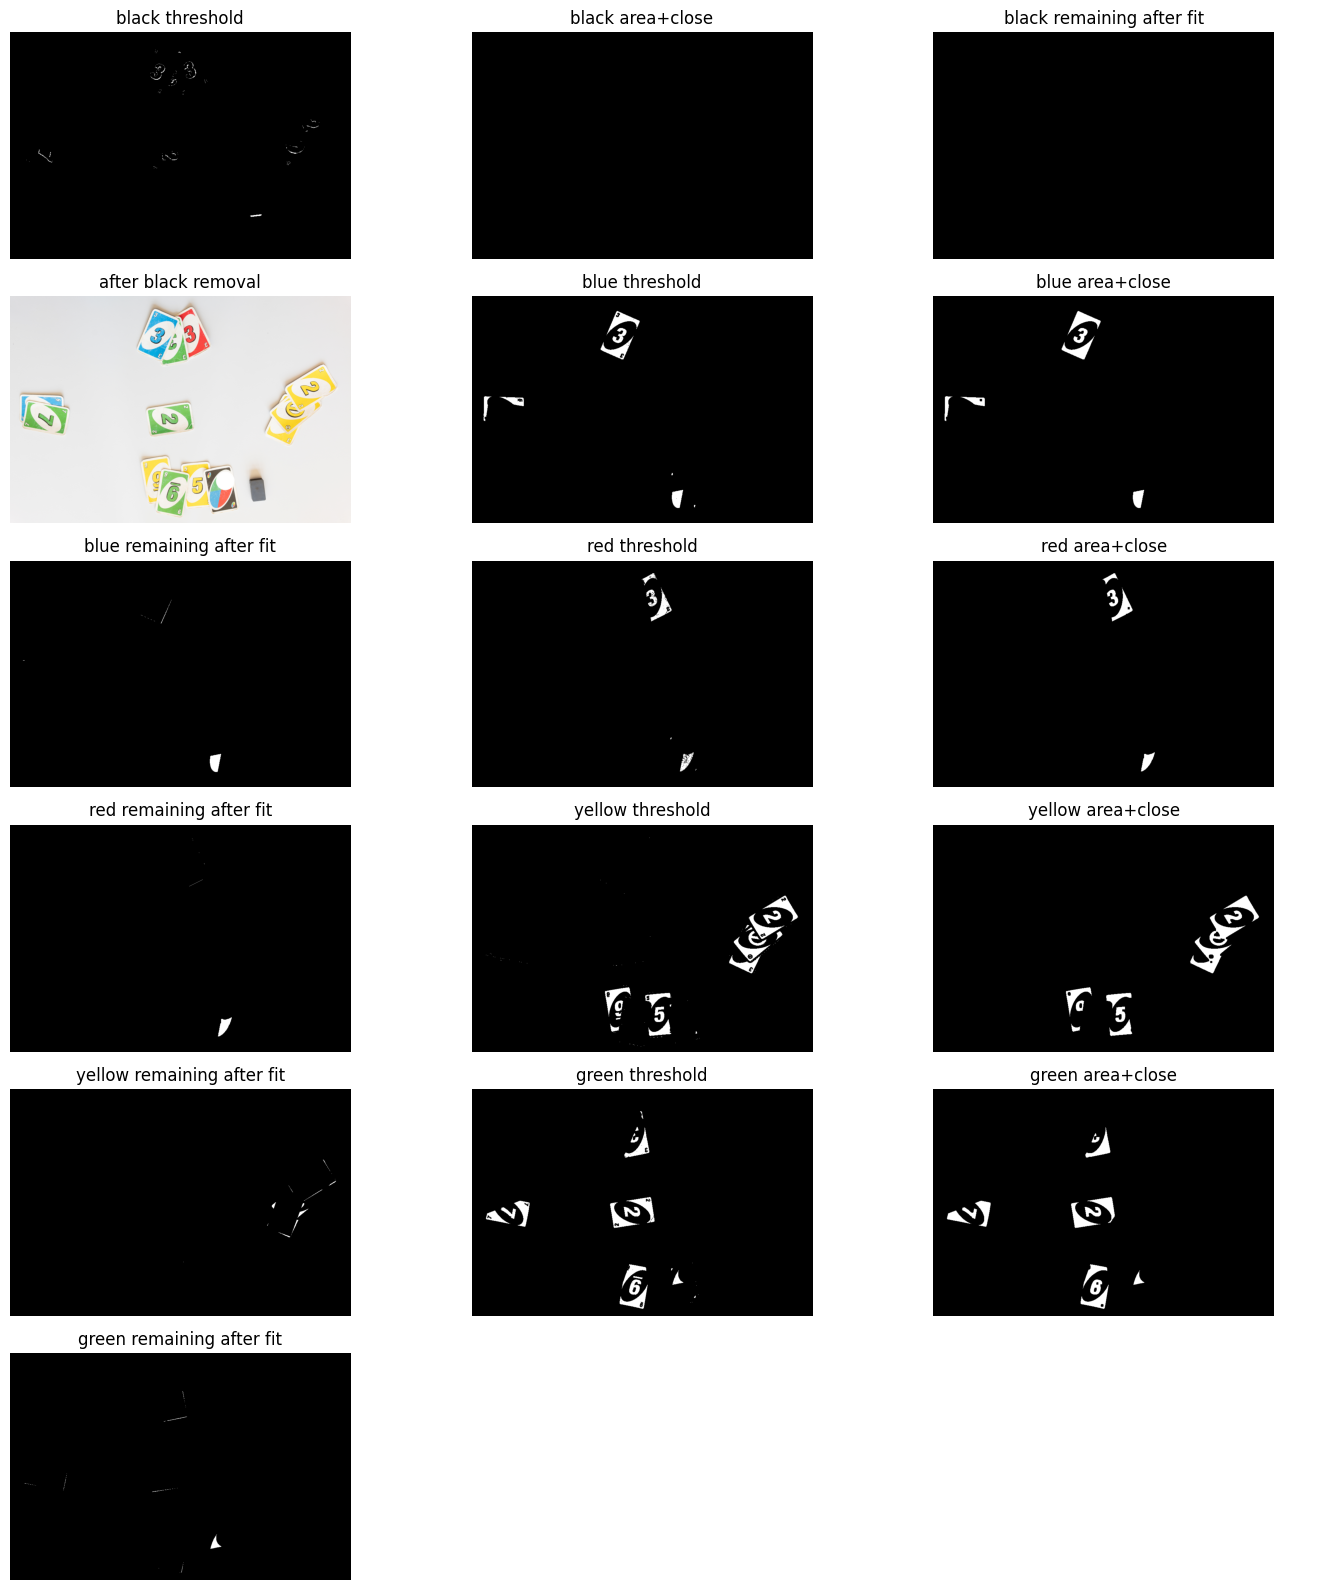

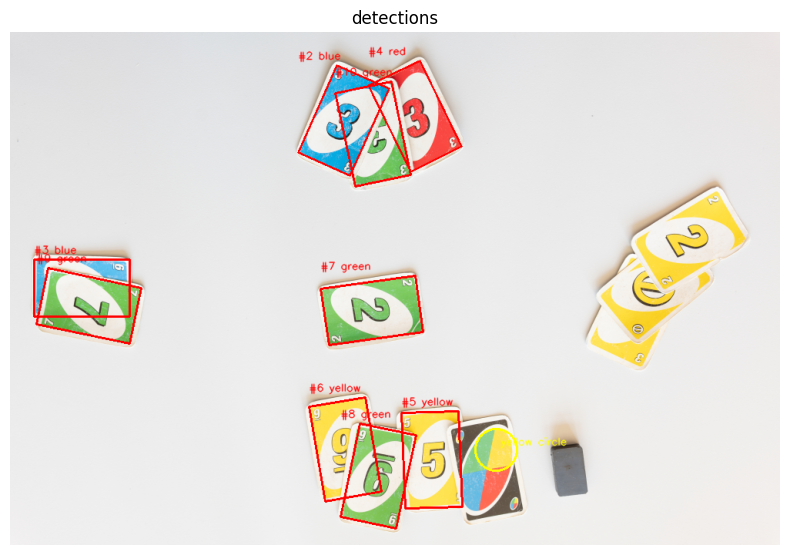

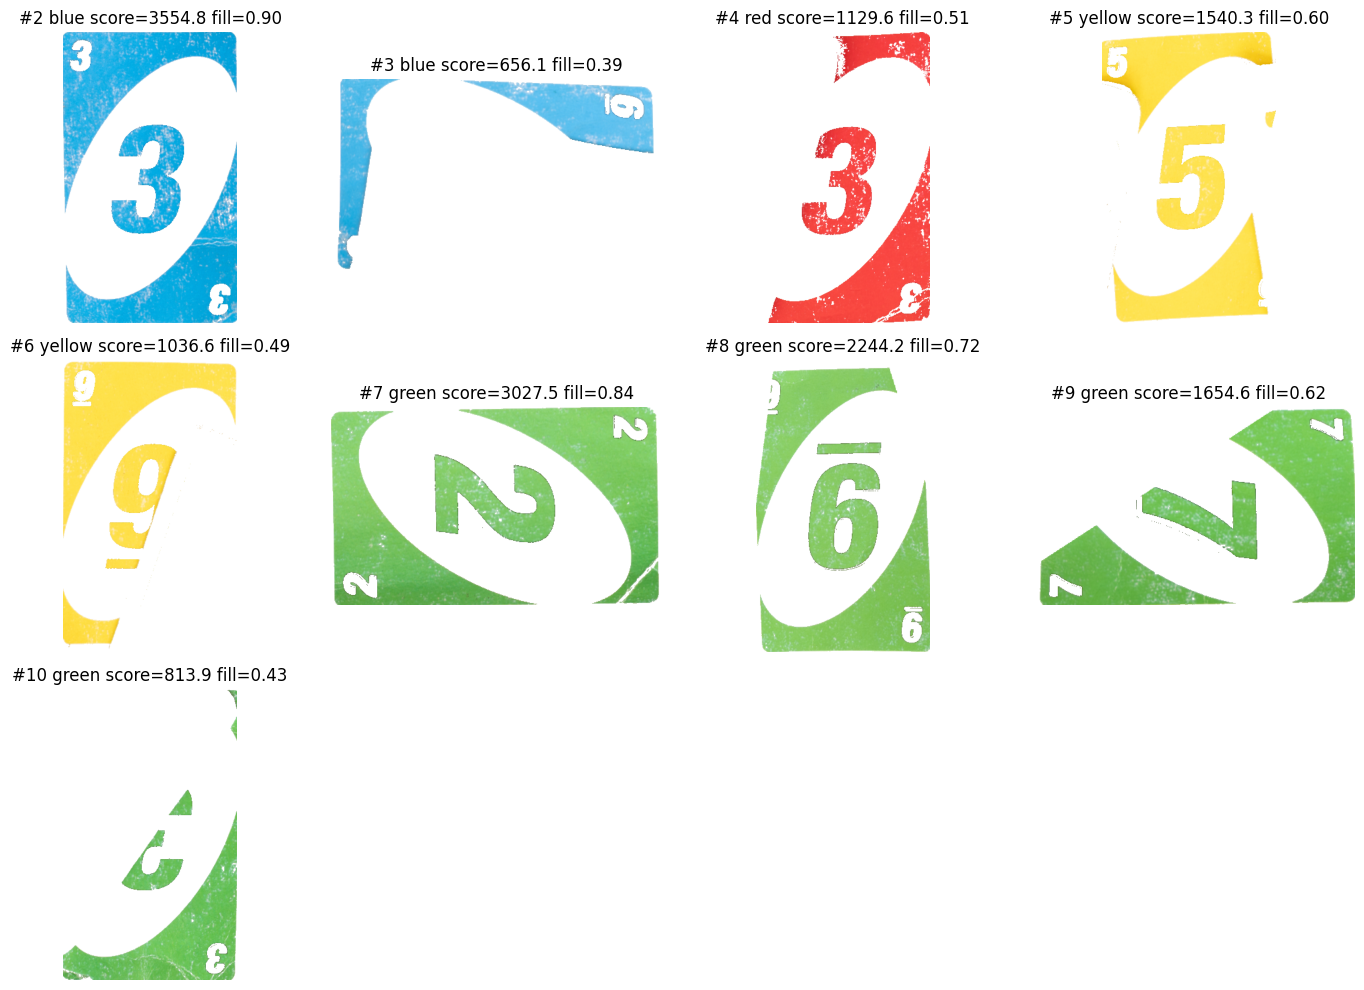

In [4]:
show_detection_result(result)

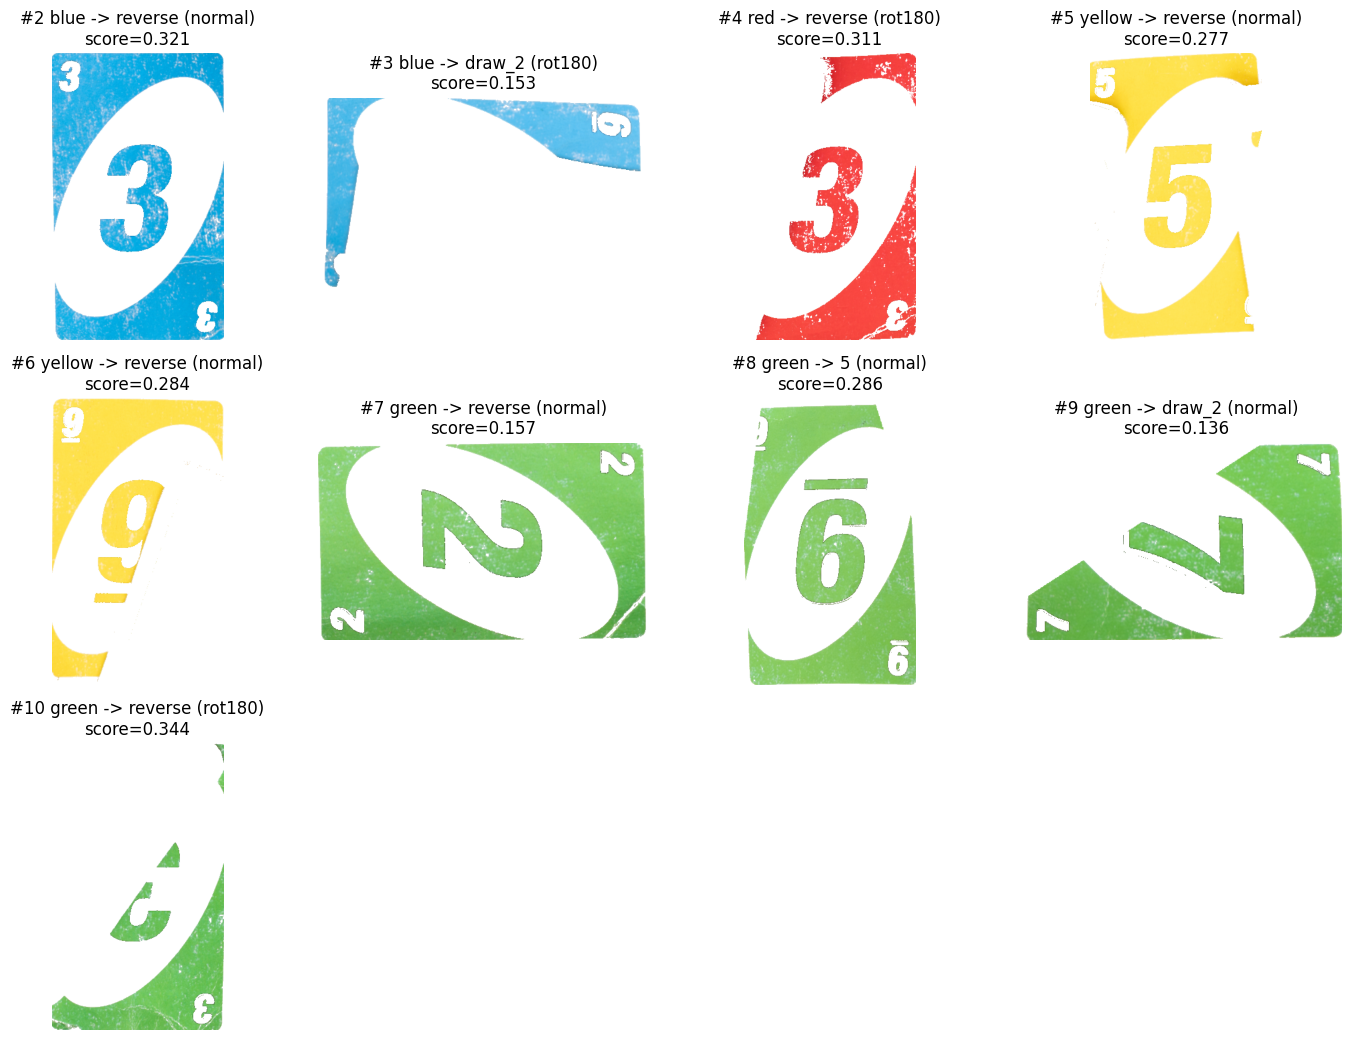

In [5]:
card_items = [item for item in classifications if item["type"] == "card"]
if not card_items:
    print("No classified cards to preview.")
else:
    cols = 4
    rows = int(np.ceil(len(card_items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, item in zip(axes, card_items):
        ax.imshow(item["crop_rgb"])
        ax.set_title(f"#{item['rank']} {item['color']} -> {item['prediction']} ({item['orientation']})\nscore={item['score']:.3f}")
        ax.axis("off")
    for ax in axes[len(card_items):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()